In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)
import shap

from scripts.preprocess import load_preprocessed_data

## Feature Engineering

Two parallel targets from the same feature matrix:
- **Regression** → `profit` (€): where is value created or destroyed?
- **Classification** → `is_loss` (profit < 0): will this task lose money?

### Design Decisions
1. `rework_ratio` (rework_hours / hours_spent) captures efficiency erosion, normalised across task sizes. Capped at 1.0 for the 67 ambiguous rows where rework > hours.
2. `billable_hours` dropped because collinear with `hours_spent` and downstream of pricing.
3. `revenue`, `cost` excluded because it's a direct components of `profit` (leakage).

In [44]:
df = load_preprocessed_data("data/ai_productivity_dataset_final.csv")

In [45]:
REG_TARGET = "profit"
CLF_TARGET = "is_loss"

In [46]:
# columns excluded from features (leakage, identifiers, collinear, or target-derived)
LEAK_COLS = ["revenue", "cost", "billable_hours", "is_loss", "profit"]
ID_COLS = ["task_id", "client", "project_id", "created_by", "jira_ticket"]
DATE_COLS = ["created_at", "delivered_at", "updated_at"]
META_COLS = ["task_status", "workflow_stage", "content_version"]
REDUNDANT_COLS = ["ai_assisted", "legacy_ai_flag", "rework_hours"]   # absorbed by ai_usage_pct / rework_ratio
DROP_COLS = LEAK_COLS + ID_COLS + DATE_COLS + META_COLS + REDUNDANT_COLS

ORDINAL_COLS = ["seniority", "deadline_pressure", "client_tier"]
ORDINAL_CATEGORIES = [
    ["junior", "mid", "senior"],
    ["low", "medium", "high"],
    ["low", "mid", "high"],
]

NOMINAL_COLS = ["pricing_model", "task_type", "team"]

In [47]:
def add_rework_ratio(df):
    """Fraction of effort spent on rework, capped at 1.0 for ambiguous rows."""
    df = df.copy()
    df["rework_ratio"] = (df["rework_hours"] / df["hours_spent"]).clip(upper=1.0)
    return df


def select_features(df):
    """Drop leakage / id / metadata columns, return feature-only DataFrame."""
    return df.drop(columns=[c for c in DROP_COLS if c in df.columns])


def identify_column_groups(X):
    """Split columns into passthrough-numeric, ordinal, and nominal groups."""
    passthrough = [c for c in X.columns if c not in ORDINAL_COLS + NOMINAL_COLS]
    return passthrough, ORDINAL_COLS, NOMINAL_COLS


def build_preprocessor(passthrough_cols, ordinal_cols, nominal_cols):
    """ColumnTransformer: passthrough numerics, ordinal-encode ordered cats, one-hot nominals."""
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", passthrough_cols),
            ("ord", OrdinalEncoder(categories=ORDINAL_CATEGORIES), ordinal_cols),
            ("nom", OneHotEncoder(drop="first", sparse_output=False, dtype=int), nominal_cols),
        ],
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")

In [48]:
df = add_rework_ratio(df)
y_reg, y_clf = df[REG_TARGET], df[CLF_TARGET]
X_raw = select_features(df)

mask = X_raw.notna().all(axis=1) & y_reg.notna()
X_raw, y_reg, y_clf = X_raw[mask].reset_index(drop=True), y_reg[mask].reset_index(drop=True), y_clf[mask].reset_index(drop=True)

passthrough, ordinal, nominal = identify_column_groups(X_raw)
preprocessor = build_preprocessor(passthrough, ordinal, nominal)
X = preprocessor.fit_transform(X_raw)

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Regression target (profit):  mean={y_reg.mean():.0f}€, std={y_reg.std():.0f}€")
print(f"Classification target (is_loss): {y_clf.mean():.1%} positive rate")

Feature matrix: 2765 rows × 25 features
Regression target (profit):  mean=357€, std=901€
Classification target (is_loss): 24.6% positive rate


## Random Forest — Regression & Classification

Both models are trained on an 80/20 split with the same random seed for comparability.
We evaluate on the held-out test set, then compute SHAP values on test data so explanations reflect generalisation, not memorisation.

In [49]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42,
)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

Train: 2212  Test: 553


### Fit & Evaluate

Regression (profit €)
	R²:  0.110
	MAE: 439€
Classification (is_loss)
	ROC-AUC: 0.729
              precision    recall  f1-score   support

  profitable       0.78      0.92      0.84       421
        loss       0.42      0.19      0.26       132

    accuracy                           0.74       553
   macro avg       0.60      0.55      0.55       553
weighted avg       0.70      0.74      0.71       553



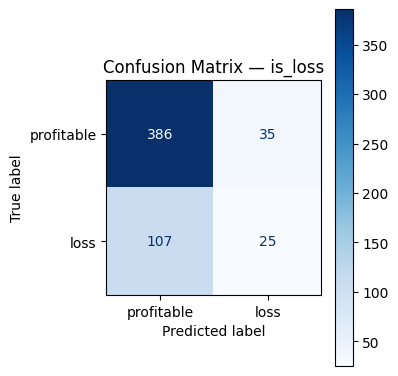

In [50]:
def fit_and_evaluate_regressor(X_tr, y_tr, X_te, y_te):
    """Fit RF regressor and print test-set metrics."""
    model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    print("Regression (profit €)")
    print(f"\tR²:  {r2_score(y_te, preds):.3f}")
    print(f"\tMAE: {mean_absolute_error(y_te, preds):.0f}€")
    return model


def fit_and_evaluate_classifier(X_tr, y_tr, X_te, y_te):
    """Fit RF classifier and print test-set metrics + confusion matrix."""
    model = RandomForestClassifier(
        n_estimators=300, max_depth=12, random_state=42, n_jobs=-1, class_weight="balanced",
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    print("Classification (is_loss)")
    print(f"\tROC-AUC: {roc_auc_score(y_te, proba):.3f}")
    print(classification_report(y_te, preds, target_names=["profitable", "loss"]))

    _, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, preds, display_labels=["profitable", "loss"], ax=ax, cmap="Blues")
    ax.set_title("Confusion Matrix — is_loss")
    plt.tight_layout()
    plt.show()
    return model


rf_reg = fit_and_evaluate_regressor(X_train, y_reg_train, X_test, y_reg_test)
rf_clf = fit_and_evaluate_classifier(X_train, y_clf_train, X_test, y_clf_test)

## SHAP Analysis

TreeExplainer gives exact Shapley values for tree ensembles. All plots use **test data** so they explain generalisation behaviour.

We show:
1. **Summary (beeswarm)** — global feature importance + direction of effect
2. **Dependence plots** — how `ai_usage_pct` effect varies by `pricing_model` and `seniority`
3. **Waterfall** — single-prediction decomposition for a representative loss-making task

In [51]:
def compute_shap_values(model, X_data):
    """Compute SHAP values using TreeExplainer. Returns shap.Explanation."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_data)
    return shap_values


shap_reg = compute_shap_values(rf_reg, X_test)
shap_clf = compute_shap_values(rf_clf, X_test)

# for classification, TreeExplainer returns values per class — take class 1 (loss)
if shap_clf.values.ndim == 3:
    shap_clf = shap.Explanation(
        values=shap_clf.values[:, :, 1],
        base_values=shap_clf.base_values[:, 1],
        data=shap_clf.data,
        feature_names=shap_clf.feature_names,
    )

### 1. SHAP Summary — Beeswarm plots

Each dot is one test-set prediction. Horizontal position = SHAP value (impact on prediction), colour = feature value (red = high, blue = low). Features sorted by mean |SHAP|.

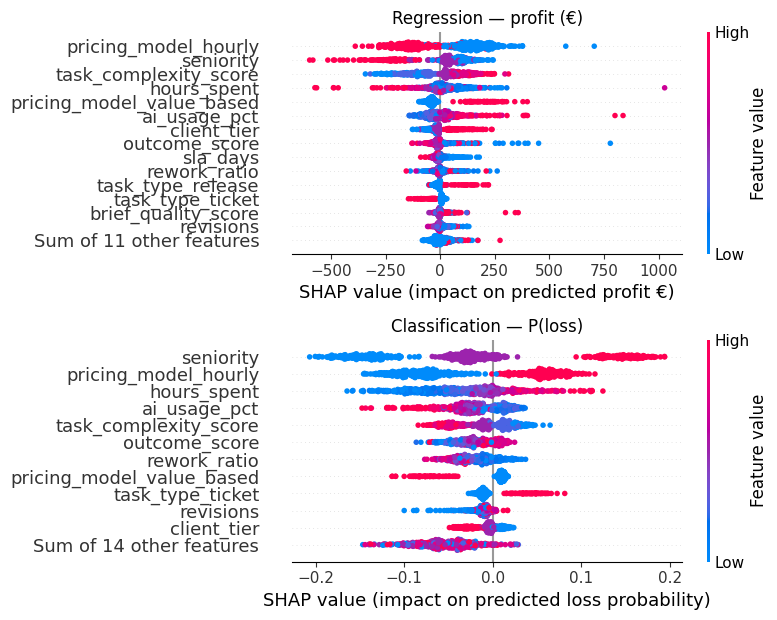

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

plt.sca(axes[0])
shap.plots.beeswarm(shap_reg, max_display=12, show=False)
axes[0].set_title("Regression — profit (€)")
axes[0].set_xlabel("SHAP value (impact on predicted profit €)")

plt.sca(axes[1])
shap.plots.beeswarm(shap_clf, max_display=12, show=False)
axes[1].set_title("Classification — P(loss)")
axes[1].set_xlabel("SHAP value (impact on predicted loss probability)")

plt.tight_layout()
plt.show()

**How to read these plots:** each row is a feature, each dot is a single task from the test set. A dot's horizontal position shows how much that feature pushed the model's prediction up (right) or down (left) *for that specific task*. Dot colour indicates the actual value of the feature: red = high, blue = low. Features are ranked top-to-bottom by overall influence.

**Regression (profit):**
- **`pricing_model_hourly`** is the single strongest driver. The red dots (hourly = 1) cluster on the left, meaning hourly pricing systematically drags profit down, often by 200-500 euros. This aligns with the EDA finding: under hourly contracts, AI-driven efficiency savings go to the client, not the agency.
- **`seniority`** shows a clear directional split: higher seniority (red) pushes profit up, lower seniority (blue) pushes it down. Senior staff generate more profitable tasks on average.
- **`task_complexity_score`** matters, but the spread is wide: complexity affects profit in a context-dependent way (some complex tasks are very profitable, others are not).
- **`ai_usage_pct`** ranks mid-table. Its effect is moderate and roughly symmetric: high AI usage (red) tends to nudge profit slightly up, but the effect is far weaker than pricing model or seniority. AI helps, but the business context around it matters more.

**Classification (P(loss)):**
- **`seniority`** is the top feature, but the direction is the *opposite* of regression: higher seniority (red) pushes the probability of loss **up**. This is not a contradiction: it can be interpreted as seniors that produce higher profit on average (regression), but their higher cost means that when things go wrong, they cross the loss threshold more easily. Juniors (blue) push P(loss) down because their lower cost acts as a buffer.
- **`pricing_model_hourly`** again appears near the top: hourly pricing (red) pushes P(loss) to the right, increasing loss probability.
- **`hours_spent`** ranks higher here than in regression: tasks that consume many hours (red) push P(loss) rightward, suggesting that long-running tasks are a risk signal for losses.
- **`ai_usage_pct`** shows a mild protective effect: higher AI usage (red) tends to push P(loss) slightly to the left, meaning AI-heavy tasks are somewhat less likely to lose money, but the effect is modest.
- **`outcome_score`** pushes in the expected direction: higher quality scores (red) reduce loss probability (dots shift left), while low scores (blue) increase it.

### 2. SHAP Dependence: AI usage conditioned on pricing model & seniority

These plots answer: *"Does AI's effect on profit change depending on the pricing model or seniority?"*
Colour encodes the interaction variable so clusters reveal conditional effects.

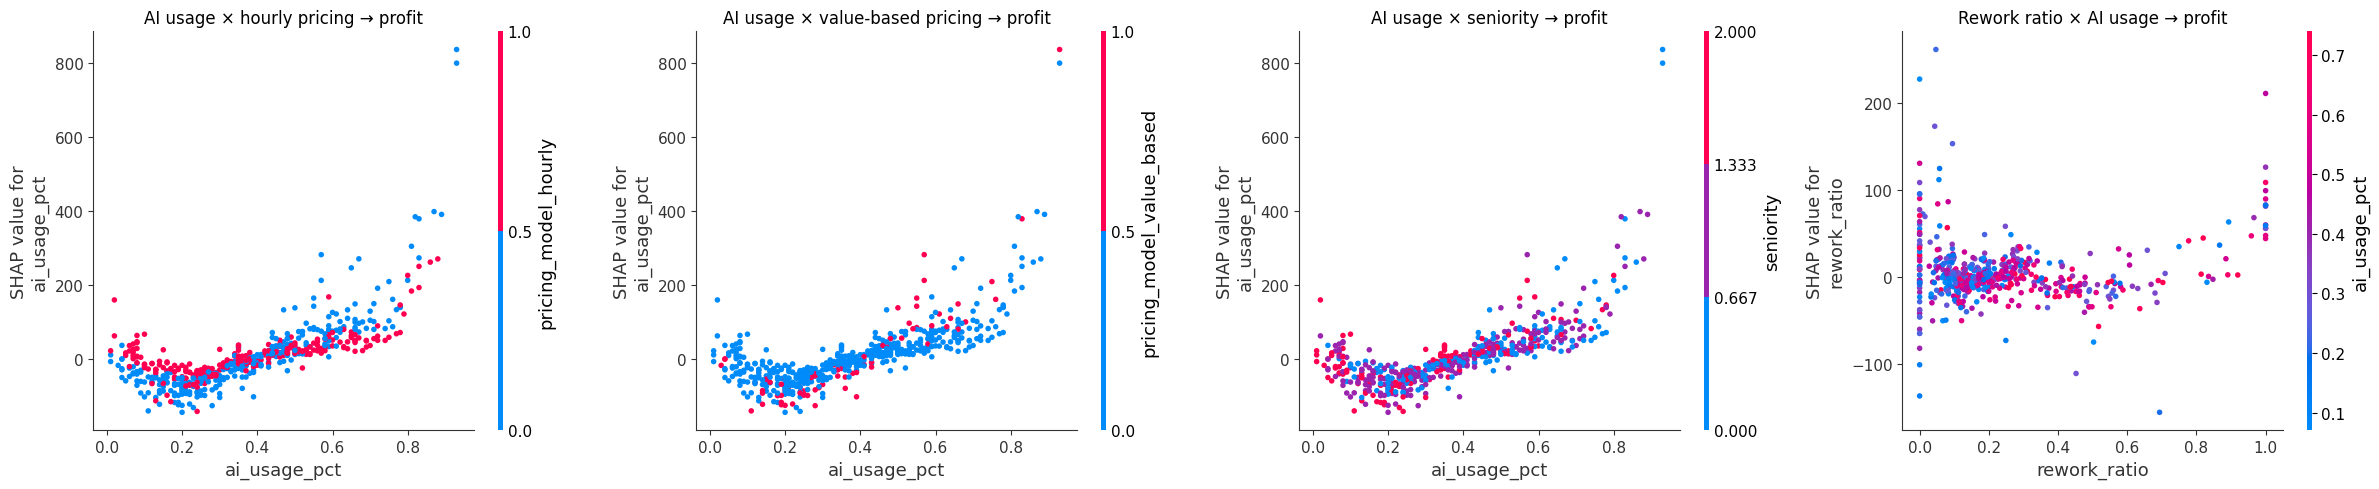

In [53]:
def shap_dependence(shap_values, feature, interaction, X_data, ax, title=None):
    """SHAP dependence plot coloured by an interaction variable."""
    shap.dependence_plot(
        feature, shap_values.values, X_data,
        interaction_index=interaction, ax=ax, show=False,
    )
    if title:
        ax.set_title(title)


dependence_pairs = [
    ("ai_usage_pct", "pricing_model_hourly", "AI usage × hourly pricing → profit"),
    ("ai_usage_pct", "pricing_model_value_based", "AI usage × value-based pricing → profit"),
    ("ai_usage_pct", "seniority", "AI usage × seniority → profit"),
    ("rework_ratio", "ai_usage_pct", "Rework ratio × AI usage → profit"),
]

fig, axes = plt.subplots(1, len(dependence_pairs), figsize=(6 * len(dependence_pairs), 5))
for ax, (feat, interact, title) in zip(axes, dependence_pairs):
    shap_dependence(shap_reg, feat, interact, X_test, ax, title)

plt.tight_layout()
plt.show()

Partial dependence plots to investigate in a deeper way the effects of interactions on the variables that have the highest shapley values. They show for one feature at a time the raw feature value on the x-value, the shapley value for that same feature in the y-axis and color based off it to reveal the interaction pattern.

They basically ask:
> _How does feature x affect profit and does that effect change depending on another variable?_

The global pattern reveals that AI usage has a **highly non linear effect on profit**. Three plots show basically the same shape where
- at very low AI usage SHAP values are around zero/mildly negative
- at moderate AI usage $\approx 0.15 - 30$, the contribution value becomes mostly negative
- at high AI usage the contribution becomes clearly positive

So the pattern is a **U shaped** or **convex effect** with strong gains when AI usage is sufficiently high.

A plausible interpretation could be that the model views AI as beneficial only once it is used deeply enough to change delivery efficiency.

The fourth plot is the only different one, showing the effect of rework ratio, modulated by AI usage.
The cloud shows:
- for small rework ratios, SHAP values are centered near zero but with high variance
- as rework ratio increases into moderate levels, contributions are mostly negative
- at very high rework ratios there are a few positive outliers, but those are sparse and should not dominate the interpretation

So the main message is that more rework implies a lower predicted profit.

### 3. Waterfall: Decomposing a single loss-making prediction

Picks the test-set task with the largest predicted loss and shows how each feature pushed the prediction away from the baseline (average profit).

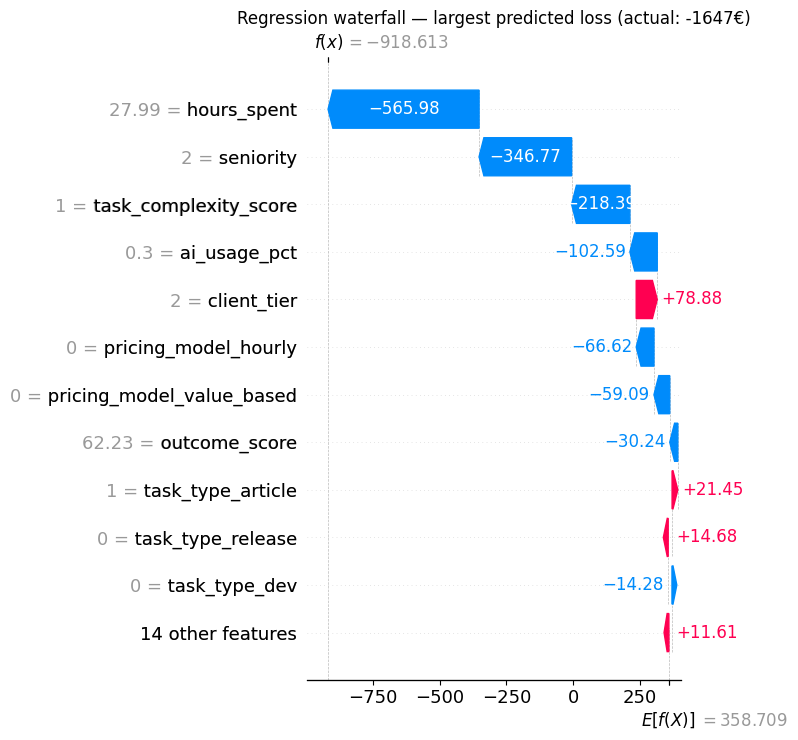

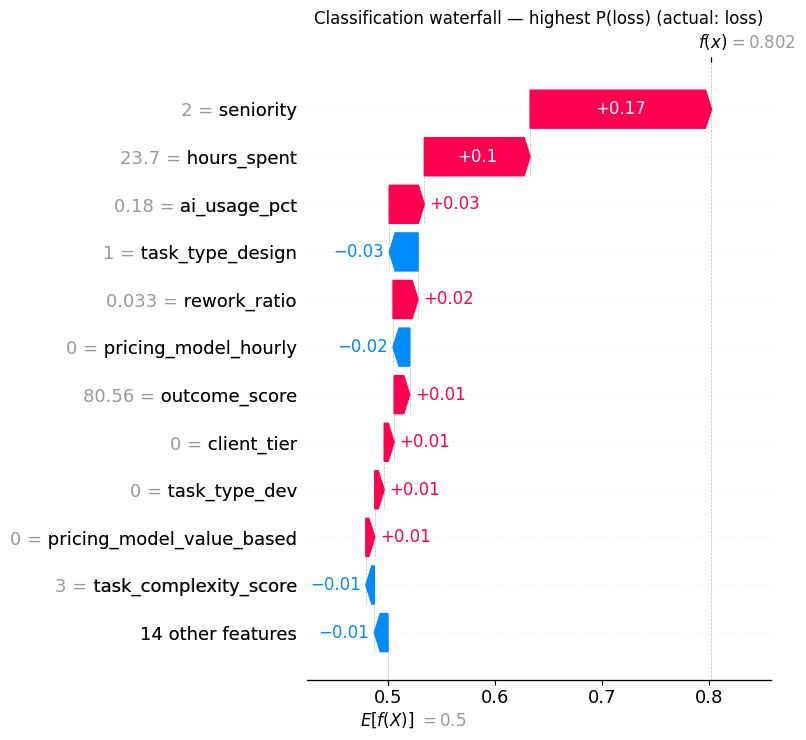

In [67]:
def plot_waterfall(shap_values, idx, title, max_display=12):
    """Waterfall plot for a single observation."""
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[idx], max_display=max_display, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# regression: worst predicted loss
worst_idx = int(np.argmin(rf_reg.predict(X_test)))
plot_waterfall(
    shap_reg, worst_idx,
    f"Regression waterfall — largest predicted loss (actual: {y_reg_test.iloc[worst_idx]:.0f}€)",
)

# classification: highest predicted P(loss)
highest_loss_prob_idx = int(np.argmax(rf_clf.predict_proba(X_test)[:, 1]))
plot_waterfall(
    shap_clf, highest_loss_prob_idx,
    f"Classification waterfall — highest P(loss) (actual: {'loss' if y_clf_test.iloc[highest_loss_prob_idx] else 'profitable'})",
)

Each bar shows how much a single feature pushed this specific task's prediction away from the baseline (the average prediction across all tasks). Blue bars push the prediction down, red bars push it up. The numbers on the left (e.g. `27.99 = hours_spent`) are the actual feature values for this task.

**Regression waterfall (actual loss: -1,647 euros):**
The story: a senior contributor spent 28 hours on a trivially simple task with moderate AI assistance and no value-based pricing to capture the value. This is a resource allocation failure, not an AI failure.

**Classification waterfall (actual: loss, predicted P(loss) = 0.80):**

The baseline is 0.50 (equal odds). The model pushes this to 0.80 (high confidence of loss):
Both models converge on the same diagnosis for loss-making tasks: the combination of senior contributors, high hours, and low-complexity or low-AI-usage tasks is where losses concentrate. The pricing model matters, but for these extreme cases the resource mismatch is the primary cause.